<a href="https://colab.research.google.com/github/shengFung/WIF3009/blob/main/gsf_WIF3009.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📦 Dataset Installation & Preparation (Kaggle + Data Engineering)

## 🎯 Objective
The goal of this phase is to build a structured, cleaned, and labeled dataset for a multi-agent AI system.  

- **Kaggle Fashion Dataset:** Used for visual feature extraction.  
- **Mercari Dataset:** Used as the ground truth for text-based pricing and conditions.




##🧩 1. Environment Setup & Library Installation
First, we install `kagglehub` to programmatically download datasets from Kaggle into our environment.

In [ ]:
# Install kagglehub for seamless dataset acquisition
!pip install kagglehub -q

import kagglehub
import pandas as pd
import numpy as np
import os
import re

print("✅ Environment Ready.")

✅ Environment Ready.


## 📥 2. Dataset Acquisition
We download both datasets. The Fashion dataset provides the images for the **Visual Agent**, while the Mercari dataset provides the resale prices and descriptions for the **Text Agent**.




In [ ]:
# Download Fashion Product Images (Small)
print("Downloading Fashion Product Images dataset...")
path_fashion = kagglehub.dataset_download("paramaggarwal/fashion-product-images-small")
df_fashion = pd.read_csv(os.path.join(path_fashion, 'styles.csv'), on_bad_lines='skip')

# Download Mercari Price Suggestion Challenge Dataset
print("Downloading Mercari dataset...")
path_mercari = kagglehub.dataset_download("rohitamalnerkar/mercari-dataset")
# Mercari data is typically a commen-seperated values (.csv) file
df_mercari = pd.read_csv(os.path.join(path_mercari, 'train2.csv'), encoding='latin1')

print(f"✅ Fashion Data: {df_fashion.shape[0]} records loaded.")
print(f"✅ Mercari Data: {df_mercari.shape[0]} records loaded.")

Using Colab cache for faster access to the 'fashion-product-images-small' dataset.


100%|██████████| 12.8M/12.8M [00:00<00:00, 69.8MB/s]

Extracting files...


✅ Fashion Data: 44424 records loaded.
✅ Mercari Data: 148253 records loaded.


## 🧼 3. Cleaning the Mercari Dataset (Market Truth)
This is the most critical cleaning step because the Mercari dataset contains our target variable (Price) and the unstructured text used to understand market value.  

- **Filter Columns**: Keep only `price`, `name`, `item_condition_id`, `category_name`, and `item_description`.  
- **Remove Outliers**: Drop rows with missing prices, prices equal to 0, or empty descriptions.  
- **Text Normalization**: Lowercase text and remove symbols to prepare for vectorization.

In [ ]:
def clean_mercari_text(text):
    if pd.isna(text): return ""
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', '', text) # Remove symbols
    return text.strip()

# Keep essential columns
essential_cols = ['price', 'name', 'item_condition_id', 'category_name', 'item_description']
df_mercari_clean = df_mercari[essential_cols].copy()

# Remove missing data and price outliers[cite: 3]
df_mercari_clean = df_mercari_clean.dropna()
df_mercari_clean = df_mercari_clean[df_mercari_clean['price'] > 0]

# Normalize text for the Price Agent[cite: 3]
df_mercari_clean['clean_description'] = df_mercari_clean['item_description'].apply(clean_mercari_text)

print(f"✅ Mercari Cleaning Complete. Remaining records: {len(df_mercari_clean)}")

✅ Mercari Cleaning Complete. Remaining records: 147530


## 🖼️ 4. Preparing the Fashion Dataset (Visual Foundation)
For the Fashion dataset, the primary goal is ensuring image paths are valid and descriptions are consistent




In [ ]:
# Map absolute image paths for the Visual Agent
df_fashion['image_path'] = df_fashion['id'].apply(lambda x: os.path.join(path_fashion, 'images', f"{x}.jpg"))

# Verify image files exist on disk[cite: 3]
df_fashion['file_exists'] = df_fashion['image_path'].apply(os.path.exists)
df_fashion_final = df_fashion[df_fashion['file_exists'] == True].drop(columns=['file_exists'])

print(f"✅ Fashion Image Mapping Complete. Verified images: {len(df_fashion_final)}")

✅ Fashion Image Mapping Complete. Verified images: 44419


##🏷️ 5. Final Data Filtering

###5.1 Filtering the Mercari Dataset

The Mercari dataset contains varied categories like Electronics and Home. For this project, you must narrow the data down to core fashion categories.  
- **Categories Kept:** Women, Men, and Kids.  
- **Categories Removed:** Electronics, Home, Beauty, Sports (Equipment), etc.

In [ ]:
# Define the splitting function to handle the hierarchical strings
def split_cat(text):
    try:
        return text.split("/")
    except:
        # Handles rows with missing or malformed category names
        return ("No Category", "No Category", "No Category")

# Create the 'main_cat' column by splitting the original 'category_name'
# Note: Ensure df_mercari_clean contains the original 'category_name' column
df_mercari_clean['main_cat'], df_mercari_clean['sub_cat1'], df_mercari_clean['sub_cat2'] = \
    zip(*df_mercari_clean['category_name'].apply(lambda x: split_cat(x)))

# Now perform the filtering for fashion-related categories
fashion_categories = ['Women', 'Men', 'Kids']
df_mercari_fashion = df_mercari_clean[df_mercari_clean['main_cat'].isin(fashion_categories)].copy()

# Drop the original category_name if it is no longer needed
df_mercari_fashion = df_mercari_fashion.drop(columns=['category_name'])

print(f"✅ Successfully filtered. Total fashion records: {len(df_mercari_fashion)}")

✅ Successfully filtered. Total fashion records: 92993


### 5.2 Filtering the Fashion Dataset
The Kaggle fashion dataset includes many beauty and household items that will interfere with the **Visual Agent's** ability to learn apparel styles.  

- **Categories Removed:** All grooming, beauty, and non-wearable household items (e.g., `Fragrance`, `Water Bottle`, `Home Furnishing`).

In [ ]:
# To see all unique categories in the cleaned Fashion dataset
unique_categories = df_fashion_final['subCategory'].unique()

print(f"Total Unique Categories: {len(unique_categories)}")
print(unique_categories)

Total Unique Categories: 45
['Topwear' 'Bottomwear' 'Watches' 'Socks' 'Shoes' 'Belts' 'Flip Flops'
 'Bags' 'Innerwear' 'Sandal' 'Shoe Accessories' 'Fragrance' 'Jewellery'
 'Lips' 'Saree' 'Eyewear' 'Nails' 'Scarves' 'Dress'
 'Loungewear and Nightwear' 'Wallets' 'Apparel Set' 'Headwear' 'Mufflers'
 'Skin Care' 'Makeup' 'Free Gifts' 'Ties' 'Accessories' 'Skin'
 'Beauty Accessories' 'Water Bottle' 'Eyes' 'Bath and Body' 'Gloves'
 'Sports Accessories' 'Cufflinks' 'Sports Equipment' 'Stoles' 'Hair'
 'Perfumes' 'Home Furnishing' 'Umbrellas' 'Wristbands' 'Vouchers']


In [ ]:
# List of non-apparel categories to drop
to_drop = [
    'Fragrance', 'Perfumes', 'Lips', 'Nails', 'Skin Care', 'Skin',
    'Makeup', 'Eyes', 'Bath and Body', 'Hair', 'Beauty Accessories',
    'Home Furnishing', 'Water Bottle', 'Umbrellas', 'Vouchers',
    'Free Gifts', 'Sports Equipment'
]

# Assuming your fashion dataframe is named df_fashion_final
df_fashion_apparel = df_fashion_final[~df_fashion_final['subCategory'].isin(to_drop)].copy()

print(f"✅ Successfully filtered. Total fashion records: {len(df_fashion_apparel)}")

✅ Successfully filtered. Total fashion records: 41875


## 💾 6. Final Output
The cleaned datasets are now ready for the next phase: **Feature Engineering**, where we will extract visual vectors from the Fashion images and text vectors from the Mercari descriptions.

In [ ]:
# Export cleaned data for the next phase
df_mercari_clean.to_csv("mercari_cleaned.csv", index=False)
df_fashion_apparel.to_csv("fashion_prepared.csv", index=False)

print("-" * 30)
print("🏁 DATASET INSTALLATION & PREPARATION COMPLETE")
print("-" * 30)

------------------------------
🏁 DATASET INSTALLATION & PREPARATION COMPLETE
------------------------------


# 📊 EDA Task Cleaning
## Fashion Product Price Analysis

This section performs exploratory data analysis to understand how different product features affect pricing.

### 🔍 Main Analysis Sections

1. **Price Distribution**
2. **Brand vs Price Analysis**
3. **Category vs Price Analysis**
4. **Condition vs Price Analysis**
5. **Correlation Heatmap**
6. **Outlier Detection**

---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import glob
import warnings

warnings.filterwarnings("ignore")

# Create folder to save graphs and output files
os.makedirs("eda_plots", exist_ok=True)
os.makedirs("eda_outputs", exist_ok=True)

print("Libraries imported successfully.")
print("Folders created: eda_plots/ and eda_outputs/")

Libraries imported successfully.
Folders created: eda_plots/ and eda_outputs/


## Load dataset for EDA task


In [ ]:
df_eda = None

# Option 1: Use existing dataframe from notebook
if "df_mercari" in globals():
    df_eda = df_mercari.copy()
    print("Using dataframe: df_mercari")

elif "df" in globals():
    possible_cols = set(df.columns)
    mercari_cols = {"price", "item_condition_id", "category_name"}

    if mercari_cols.issubset(possible_cols):
        df_eda = df.copy()
        print("Using dataframe: df")

# Option 2: Try loading saved files
if df_eda is None:
    possible_files = [
        "mercari_cleaned.csv",
        "clean_mercari.csv",
        "data/clean_mercari.csv",
        "mercari.csv",
        "train.csv",
        "train.tsv",
        "data/train.tsv"
    ]

    loaded = False

    for file in possible_files:
        if os.path.exists(file):
            if file.endswith(".tsv"):
                df_eda = pd.read_csv(file, sep="\t")
            else:
                df_eda = pd.read_csv(file)

            print(f"Loaded file: {file}")
            loaded = True
            break

    if not loaded:
        all_csv_tsv = glob.glob("*.csv") + glob.glob("*.tsv") + glob.glob("data/*.csv") + glob.glob("data/*.tsv")
        print("Available CSV/TSV files found:", all_csv_tsv)
        raise FileNotFoundError(
            "No Mercari dataset found. Please run your teammate's cells first or upload mercari_cleaned.csv / train.tsv."
        )

print("Dataset loaded successfully.")
print("Shape:", df_eda.shape)
print("Columns:")
print(df_eda.columns.tolist())

Using dataframe: df_mercari
Dataset loaded successfully.
Shape: (148253, 8)
Columns:
['train_id', 'name', 'item_condition_id', 'category_name', 'brand_name', 'price', 'shipping', 'item_description']


## Cleaned dataset for EDA

In [ ]:
df_eda.columns = df_eda.columns.str.strip()

# Required column check
required_columns = ["price", "item_condition_id", "category_name"]

for col in required_columns:
    if col not in df_eda.columns:
        raise ValueError(f"Missing required column: {col}")

# Keep useful columns only if they exist
useful_columns = [
    "price",
    "name",
    "item_condition_id",
    "category_name",
    "brand_name",
    "item_description"
]

available_columns = [col for col in useful_columns if col in df_eda.columns]
df_eda = df_eda[available_columns].copy()

# Convert price to numeric
df_eda["price"] = pd.to_numeric(df_eda["price"], errors="coerce")

# Remove missing price and invalid price
df_eda = df_eda.dropna(subset=["price"])
df_eda = df_eda[df_eda["price"] > 0]

# Handle missing brand column
if "brand_name" not in df_eda.columns:
    df_eda["brand_name"] = "Unknown"
else:
    df_eda["brand_name"] = df_eda["brand_name"].fillna("Unknown")
    df_eda["brand_name"] = df_eda["brand_name"].astype(str).str.strip()
    df_eda["brand_name"] = df_eda["brand_name"].replace("", "Unknown")

# Handle missing text columns
if "name" not in df_eda.columns:
    df_eda["name"] = ""

if "item_description" not in df_eda.columns:
    df_eda["item_description"] = ""

df_eda["name"] = df_eda["name"].fillna("").astype(str)
df_eda["item_description"] = df_eda["item_description"].fillna("").astype(str)
df_eda["category_name"] = df_eda["category_name"].fillna("Unknown").astype(str)

print("Basic cleaning completed.")
print("Shape after cleaning:", df_eda.shape)
df_eda.head()

Basic cleaning completed.
Shape after cleaning: (148169, 6)


,price,name,item_condition_id,category_name,brand_name,item_description
0,12.0,Hero 77 fountain pen,2,Other/Office supplies/Writing,Unknown,"For sale a brand new Hero 77 fountain pen, doe..."
1,20.0,14K Yellow Gold Earrings,3,Women/Jewelry/Earrings,Unknown,14k black Onyx earrings Good condition Final sale
2,10.0,New balance 2-in 1 size S dry fit shorts,2,Women/Athletic Apparel/Shorts,New Balance,"Brand new never worn, but I tore the tag off w..."
3,15.0,Zella black workout tank w mesh cut out,3,Women/Athletic Apparel/Shirts & Tops,Zella,Zella black workout tank with mesh cut outs.
4,75.0,NWT Lilly Pulitzer gabby dress sz 8,1,"Women/Dresses/Above Knee, Mini",Lilly Pulitzer,New with tags!! Size 8.


##Category Splitting

In [ ]:
def split_category(category):
    parts = str(category).split("/")

    while len(parts) < 3:
        parts.append("Unknown")

    return parts[0], parts[1], parts[2]

df_eda[["main_category", "sub_category_1", "sub_category_2"]] = df_eda["category_name"].apply(
    lambda x: pd.Series(split_category(x))
)

print("Category columns created.")
df_eda[["category_name", "main_category", "sub_category_1", "sub_category_2"]].head()

Category columns created.


,category_name,main_category,sub_category_1,sub_category_2
0,Other/Office supplies/Writing,Other,Office supplies,Writing
1,Women/Jewelry/Earrings,Women,Jewelry,Earrings
2,Women/Athletic Apparel/Shorts,Women,Athletic Apparel,Shorts
3,Women/Athletic Apparel/Shirts & Tops,Women,Athletic Apparel,Shirts & Tops
4,"Women/Dresses/Above Knee, Mini",Women,Dresses,"Above Knee, Mini"


## condition Mapping

In [ ]:
condition_map = {
    1: "New",
    2: "Used",
    3: "Used",
    4: "Worn",
    5: "Worn"
}

df_eda["condition_label"] = df_eda["item_condition_id"].map(condition_map)
df_eda["condition_label"] = df_eda["condition_label"].fillna("Unknown")

print("Condition labels created.")
print(df_eda["condition_label"].value_counts())

Condition labels created.
condition_label
Used    80612
New     64154
Worn     3403
Name: count, dtype: int64


## product type classification
Hoodie vs Jacket vs T-shirt

In [ ]:
def classify_product_type(row):
    text = (
        str(row["name"]) + " " +
        str(row["item_description"]) + " " +
        str(row["category_name"]) + " " +
        str(row["sub_category_1"]) + " " +
        str(row["sub_category_2"])
    ).lower()

    if re.search(r"\bhoodie\b|\bhooded\b|\bsweatshirt\b", text):
        return "Hoodie"
    elif re.search(r"\bjacket\b|\bcoat\b|\bblazer\b|\bwindbreaker\b", text):
        return "Jacket"
    elif re.search(r"\bt-shirt\b|\btshirt\b|\btee\b|\btees\b", text):
        return "T-shirt"
    else:
        return "Other"

df_eda["product_type"] = df_eda.apply(classify_product_type, axis=1)

print("Product type classification completed.")
print(df_eda["product_type"].value_counts())

Product type classification completed.
product_type
Other      138203
T-shirt      3379
Jacket       3342
Hoodie       3245
Name: count, dtype: int64


# 📊EDA Graphical representation

## 1.Price distribution

The price distribution analysis shows how product prices are spread across the dataset.  
A histogram is used to understand whether most products are low-priced, medium-priced, or high-priced.  
A boxplot is also used to identify extreme price values, which may represent luxury items, rare products, or incorrect listings.

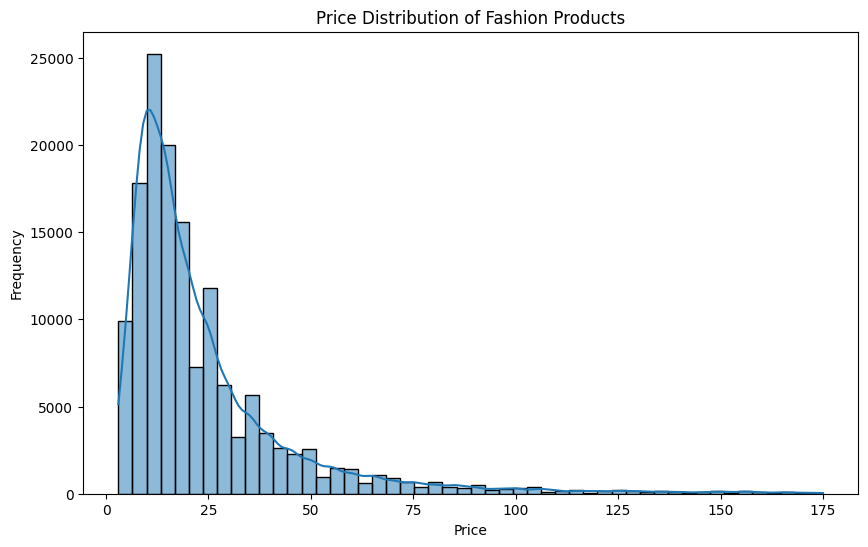

In [ ]:
price_99 = df_eda["price"].quantile(0.99)

plt.figure(figsize=(10, 6))

sns.histplot(
    df_eda[df_eda["price"] <= price_99]["price"],
    bins=50,
    kde=True
)

plt.title("Price Distribution of Fashion Products")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.savefig("eda_plots/01_price_distribution_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

## 2.Brand vs Price analysis

Brand analysis compares the average and median prices of different brands.  
This helps identify which brands are generally priced higher in the resale market.  
To make the result more reliable, brands with very few listings are removed because their average price may be misleading.

### Top 10 brands by average price graph
### Average price per top frequent brand

Top 10 brands by average price:


,brand_name,average_price,median_price,listing_count
467,Christian Louboutin,199.861111,218.0,36
1236,Louis Vuitton,192.498442,105.0,321
404,Canon,116.440476,53.5,84
327,Bose,107.470588,73.5,34
865,Gucci,104.425287,82.0,174
1475,Nikon,103.205128,81.0,39
1654,Prada,99.952381,59.5,42
1929,Spin Master,99.177778,106.0,45
443,Chanel,95.122807,35.0,228
2057,Tiffany & Co.,94.556391,74.0,133


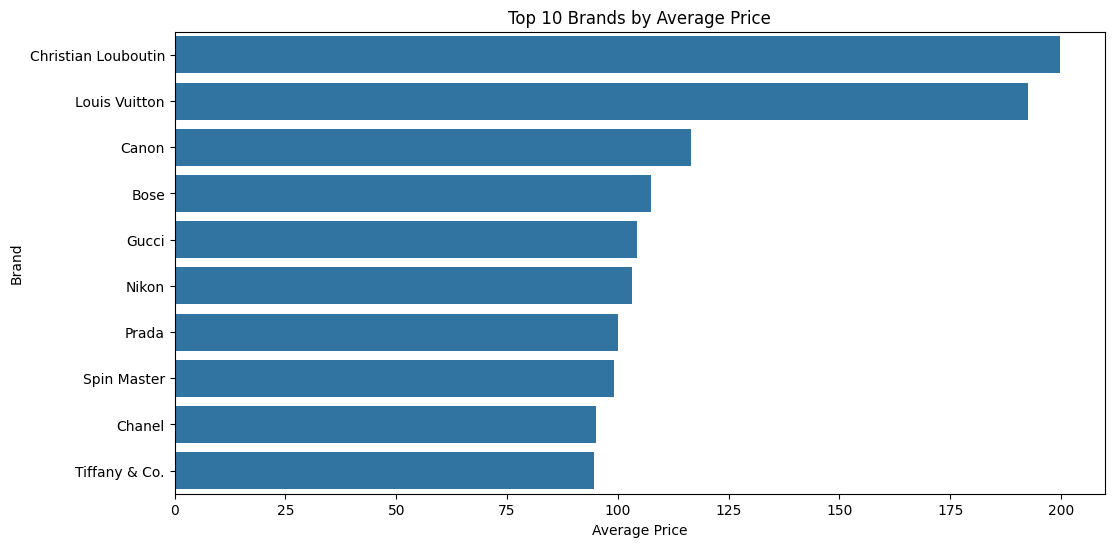

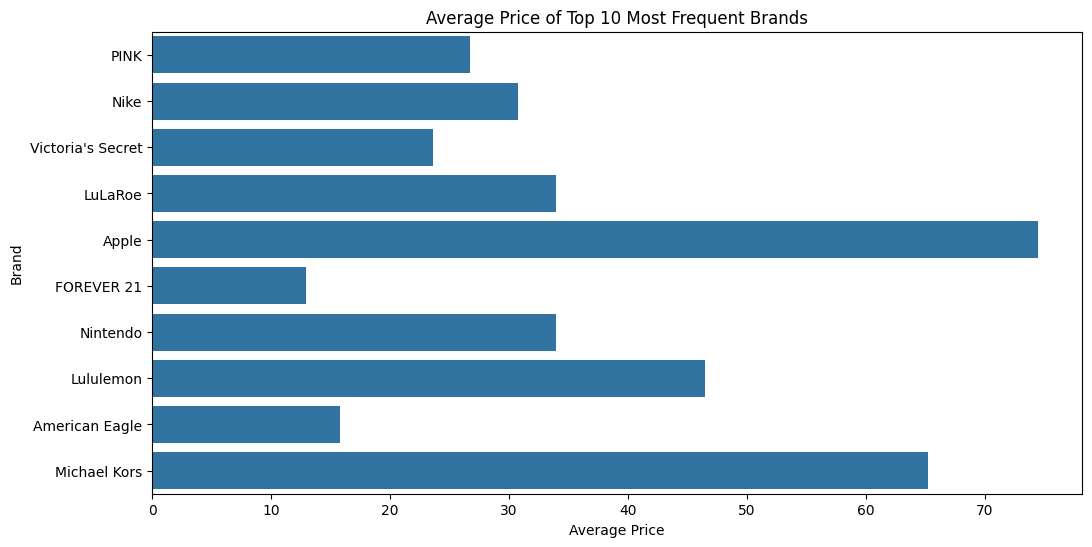

,brand_name,average_price,median_price,listing_count
1556,PINK,26.759757,21.0,5355
1473,Nike,30.800938,22.0,5330
2165,Victoria's Secret,23.596656,19.0,4785
1242,LuLaRoe,33.945833,29.0,3120
131,Apple,74.469084,22.0,1682
724,FOREVER 21,12.923679,12.0,1533
1479,Nintendo,33.951668,20.0,1469
1252,Lululemon,46.531184,39.0,1427
103,American Eagle,15.804396,14.0,1365
1357,Michael Kors,65.277652,50.0,1329


In [ ]:
brand_df = df_eda[df_eda["brand_name"] != "Unknown"].copy()

brand_summary = brand_df.groupby("brand_name").agg(
    average_price=("price", "mean"),
    median_price=("price", "median"),
    listing_count=("price", "count")
).reset_index()

# Keep only brands with enough listings
brand_summary_filtered = brand_summary[brand_summary["listing_count"] >= 30].copy()

# If too few brands remain, reduce threshold automatically
if len(brand_summary_filtered) < 10:
    brand_summary_filtered = brand_summary[brand_summary["listing_count"] >= 10].copy()

if len(brand_summary_filtered) < 10:
    brand_summary_filtered = brand_summary.copy()

top_10_brands_by_price = brand_summary_filtered.sort_values(
    by="average_price",
    ascending=False
).head(10)

print("Top 10 brands by average price:")
display(top_10_brands_by_price)

brand_summary.to_csv("eda_outputs/brand_price_summary.csv", index=False)
top_10_brands_by_price.to_csv("eda_outputs/top_10_brands_by_average_price.csv", index=False)


# top 10 graph
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_10_brands_by_price,
    x="average_price",
    y="brand_name"
)

plt.title("Top 10 Brands by Average Price")
plt.xlabel("Average Price")
plt.ylabel("Brand")

plt.savefig("eda_plots/03_top_10_brands_by_average_price.png", dpi=300, bbox_inches="tight")
plt.show()


# frequent graph
top_10_frequent_brands = brand_summary.sort_values(
    by="listing_count",
    ascending=False
).head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_10_frequent_brands,
    x="average_price",
    y="brand_name"
)

plt.title("Average Price of Top 10 Most Frequent Brands")
plt.xlabel("Average Price")
plt.ylabel("Brand")

plt.savefig("eda_plots/04_average_price_top_frequent_brands.png", dpi=300, bbox_inches="tight")
plt.show()

display(top_10_frequent_brands)

## 3 Category Analysis
This analysis compares product pricing between Hoodies, Jackets, and T-shirts.  
Different clothing categories naturally have different price ranges.  
For example, jackets may be more expensive because they usually use more material and are often considered outerwear, while T-shirts are usually more affordable.

Category price summary:


,product_type,average_price,median_price,min_price,max_price,listing_count
0,Hoodie,26.822188,21.0,3.0,355.0,3245
1,Jacket,29.367744,22.0,3.0,331.0,3342
2,T-shirt,19.632880,15.0,3.0,774.0,3379


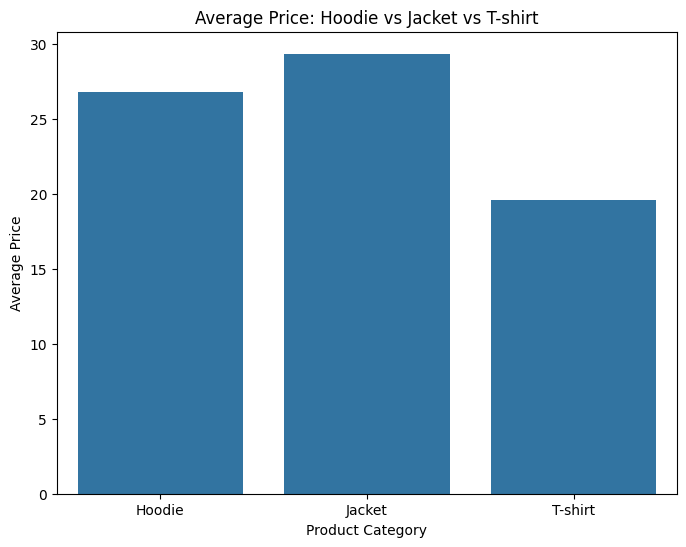

In [ ]:
category_df = df_eda[df_eda["product_type"].isin(["Hoodie", "Jacket", "T-shirt"])].copy()

category_summary = category_df.groupby("product_type").agg(
    average_price=("price", "mean"),
    median_price=("price", "median"),
    min_price=("price", "min"),
    max_price=("price", "max"),
    listing_count=("price", "count")
).reset_index()

print("Category price summary:")
display(category_summary)

category_summary.to_csv("eda_outputs/category_price_summary.csv", index=False)


plt.figure(figsize=(8, 6))

sns.barplot(
    data=category_summary,
    x="product_type",
    y="average_price",
    order=["Hoodie", "Jacket", "T-shirt"]
)

plt.title("Average Price: Hoodie vs Jacket vs T-shirt")
plt.xlabel("Product Category")
plt.ylabel("Average Price")

plt.savefig("eda_plots/05_category_average_price.png", dpi=300, bbox_inches="tight")
plt.show()

## 4.Condition Impact on Price

Condition analysis shows how the condition of a product affects its price.  
New products are usually expected to have higher prices because they are unused.  
Used products may have moderate prices, while worn products usually have lower prices due to reduced quality or visible usage.

Condition price summary:


,condition_label,average_price,median_price,min_price,max_price,listing_count
0,New,26.631465,18.0,3.0,2000.0,64154
1,Used,27.082612,17.0,3.0,1815.0,80612
2,Worn,24.289744,15.0,3.0,522.0,3403


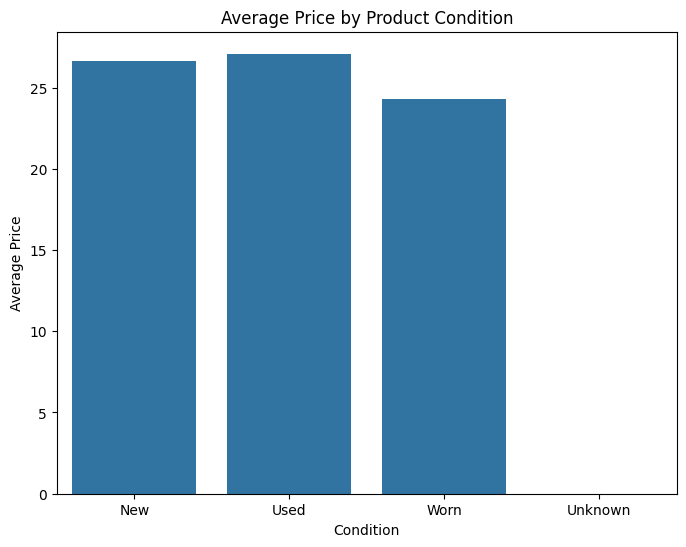

In [ ]:
condition_summary = df_eda.groupby("condition_label").agg(
    average_price=("price", "mean"),
    median_price=("price", "median"),
    min_price=("price", "min"),
    max_price=("price", "max"),
    listing_count=("price", "count")
).reset_index()

condition_order = ["New", "Used", "Worn", "Unknown"]

condition_summary["condition_label"] = pd.Categorical(
    condition_summary["condition_label"],
    categories=condition_order,
    ordered=True
)

condition_summary = condition_summary.sort_values("condition_label")

print("Condition price summary:")
display(condition_summary)

condition_summary.to_csv("eda_outputs/condition_price_summary.csv", index=False)

plt.figure(figsize=(8, 6))

sns.barplot(
    data=condition_summary,
    x="condition_label",
    y="average_price",
    order=["New", "Used", "Worn", "Unknown"]
)

plt.title("Average Price by Product Condition")
plt.xlabel("Condition")
plt.ylabel("Average Price")

plt.savefig("eda_plots/07_condition_average_price.png", dpi=300, bbox_inches="tight")
plt.show()

## 5.Correlation Heatmap
The correlation heatmap shows the relationship between selected features and price.  
Since brand, category, and condition are categorical variables, they are converted into numerical codes before calculating correlation.  
The heatmap helps identify whether any feature has a positive or negative relationship with product price.

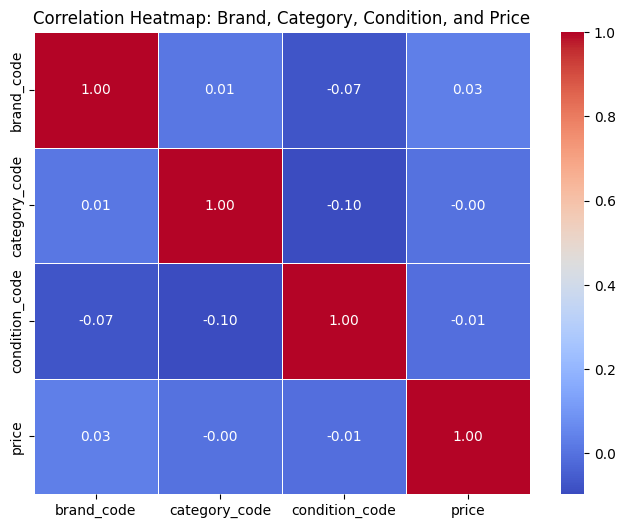

In [ ]:
corr_df = df_eda[[
    "brand_name",
    "product_type",
    "condition_label",
    "price"
]].copy()

# Convert categorical columns into numeric codes
corr_df["brand_code"] = pd.factorize(corr_df["brand_name"])[0]
corr_df["category_code"] = pd.factorize(corr_df["product_type"])[0]
corr_df["condition_code"] = pd.factorize(corr_df["condition_label"])[0]

# Correlation matrix
corr_matrix = corr_df[[
    "brand_code",
    "category_code",
    "condition_code",
    "price"
]].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap: Brand, Category, Condition, and Price")

plt.savefig("eda_plots/09_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## 6.Outlier Detection

Outlier detection is performed using the Interquartile Range method.  
The IQR method identifies prices that are much lower or much higher than the normal range.  
These outliers may represent luxury products, rare items, incorrect prices, or unusual listings.  
Detecting outliers is important because extreme values can affect the accuracy of machine learning models.

Outlier Detection Result
------------------------
Q1: 10.0
Q3: 29.0
IQR: 19.0
Lower Bound: -18.5
Upper Bound: 57.5
Number of outliers: 11988
Number of normal records: 136181
Percentage of outliers: 8.09 %


,price,name,item_condition_id,category_name,brand_name,item_description,main_category,sub_category_1,sub_category_2,condition_label,product_type
4,75.0,NWT Lilly Pulitzer gabby dress sz 8,1,"Women/Dresses/Above Knee, Mini",Lilly Pulitzer,New with tags!! Size 8.,Women,Dresses,"Above Knee, Mini",New,Other
15,359.0,MPC STUDIO BLACK,2,Other/Musical instruments/Studio Recording Equ...,Unknown,Beat Pad (if your not a serious buyer do not c...,Other,Musical instruments,Studio Recording Equipment,Used,Other
19,65.0,For monica only,2,Kids/Girls 0-24 Mos/One-Pieces,Gap,"40+ pieces of baby gap, Gymboree, Ralph Lauren...",Kids,Girls 0-24 Mos,One-Pieces,Used,Other
33,166.0,Fentys creepers,3,Women/Shoes/Fashion Sneakers,PUMA,Rihanna fentys Minor stain that's shown in sec...,Women,Shoes,Fashion Sneakers,Used,Other
34,73.0,LuLaRoe camouflage Amelia unicorn small,1,Women/Dresses/Knee-Length,Unknown,Size S Amelia with vintage camouflage print. B...,Women,Dresses,Knee-Length,New,Other


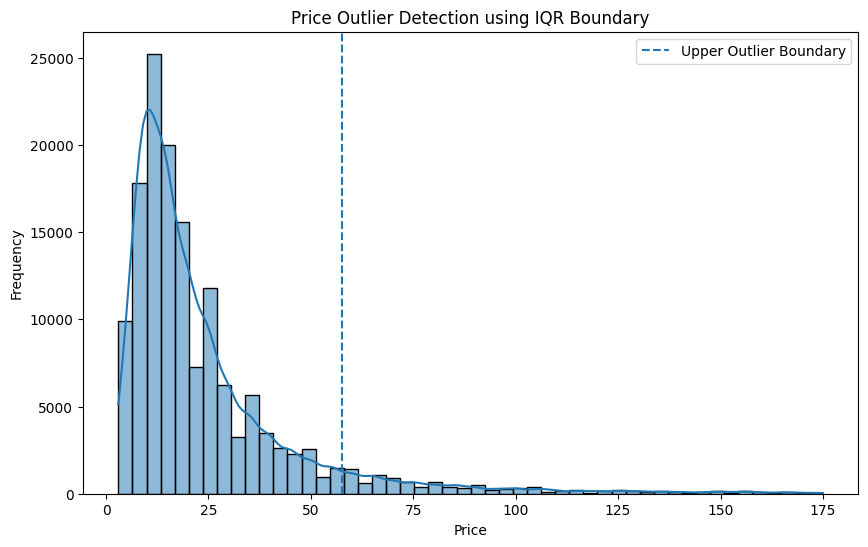

In [ ]:
Q1 = df_eda["price"].quantile(0.25)
Q3 = df_eda["price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_eda[
    (df_eda["price"] < lower_bound) |
    (df_eda["price"] > upper_bound)
].copy()

non_outliers = df_eda[
    (df_eda["price"] >= lower_bound) &
    (df_eda["price"] <= upper_bound)
].copy()

print("Outlier Detection Result")
print("------------------------")
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of outliers:", len(outliers))
print("Number of normal records:", len(non_outliers))
print("Percentage of outliers:", round((len(outliers) / len(df_eda)) * 100, 2), "%")

outliers.to_csv("eda_outputs/price_outliers.csv", index=False)
non_outliers.to_csv("eda_outputs/price_without_outliers.csv", index=False)

display(outliers.head())

plt.figure(figsize=(10, 6))

sns.histplot(
    df_eda[df_eda["price"] <= price_99]["price"],
    bins=50,
    kde=True
)

plt.axvline(upper_bound, linestyle="--", label="Upper Outlier Boundary")

plt.title("Price Outlier Detection using IQR Boundary")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.legend()

plt.savefig("eda_plots/11_outlier_detection_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

# Image Agent: Visual Feature Extraction

This section implements the **Image Agent** component, focusing on extracting visual features from the cleaned fashion apparel images using a pre-trained deep learning model.

### 🎯 Objective
To convert each apparel image into a numerical embedding vector that captures its visual characteristics. These feature vectors will be crucial inputs for the multi-agent system, allowing it to 'understand' the visual aspects of clothing items.

### 🧩 Approach
We will use `MobileNetV2`, a lightweight convolutional neural network pre-trained on the ImageNet dataset. By removing its top classification layer, we can leverage its powerful feature extraction capabilities. The images will be preprocessed to match the model's input requirements (224x224 pixels and specific normalization).

### 📦 Output
- `image_features.npy`: A NumPy array containing the extracted feature vectors for all processed images.
- `image_ids.npy`: A NumPy array containing the `id` corresponding to each feature vector, ensuring traceability.

### 🧩 Setup and Library Loading

First, we import the necessary libraries for image processing and deep learning. This includes `tensorflow` for model operations, `numpy` for array manipulation, `os` for path handling, and `PIL` (Pillow) for image loading. We also configure TensorFlow to manage GPU memory efficiently, which is crucial for handling large image datasets without running out of memory.

In [ ]:
# Import necessary libraries for image processing and model loading
import tensorflow as tf
import numpy as np
import os
from PIL import Image

# Ensure GPU memory growth to prevent out-of-memory errors on some systems
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    try:
        tf.config.experimental.set_memory_growth(physical_devices[0], True)
        print("GPU memory growth enabled.")
    except:
        # Invalid device or cannot modify virtual devices once initialized.
        print("Could not set GPU memory growth.")

print("✅ Image Agent libraries loaded.")

GPU memory growth enabled.
✅ Image Agent libraries loaded.


### 🧩 Image Preprocessing Function

This function (`preprocess_image`) is designed to take an image path, load the image, and transform it into the format expected by the MobileNetV2 model. This involves:
- **Loading and converting to RGB**: Ensures consistent image format.
- **Resizing**: Adjusts the image to `224x224` pixels, the standard input size for MobileNetV2.
- **Converting to NumPy array**: Transforms the image into a numerical array.
- **Adding a batch dimension**: Models expect a batch of images, so a dimension is added to represent a single image batch.
- **Applying MobileNetV2 preprocessing**: Scales pixel values (e.g., from 0-255 to -1 to 1) according to the model's requirements.

In [ ]:
# Define a function to load and preprocess images for MobileNetV2
def preprocess_image(image_path, target_size=(224, 224)):
    try:
        # Load the image and convert to RGB (important for consistency)
        img = Image.open(image_path).convert('RGB')
        # Resize image to the target size expected by MobileNetV2
        img = img.resize(target_size)
        # Convert the image to a NumPy array
        img_array = tf.keras.utils.img_to_array(img)
        # Add a batch dimension (e.g., from (224, 224, 3) to (1, 224, 224, 3))
        img_array = np.expand_dims(img_array, axis=0)
        # Apply MobileNetV2-specific preprocessing (scaling pixel values)
        return tf.keras.applications.mobilenet_v2.preprocess_input(img_array)
    except Exception as e:
        print(f"Error processing image {image_path}: {e}")
        return None

print("✅ Image preprocessing function defined.")

✅ Image preprocessing function defined.


### 🧩 MobileNetV2 Model Setup

Here, we load the pre-trained `MobileNetV2` model from `tf.keras.applications`. We configure it as follows:
- `input_shape=(224, 224, 3)`: Matches the preprocessed image dimensions.
- `include_top=False`: Crucially, this removes the original classification layer, allowing the model to act solely as a feature extractor.
- `weights='imagenet'`: Loads weights pre-trained on the ImageNet dataset, providing a strong foundation for visual feature extraction.

We then freeze the base model's layers (`base_model.trainable = False`) to ensure that its pre-trained weights are not altered. Finally, we create a `Sequential` model that pipelines the `base_model` with a `GlobalAveragePooling2D` layer. This pooling layer reduces the complex feature maps from MobileNetV2 into a single, fixed-size vector (1280 features in this case) for each image, which is our desired embedding.

In [ ]:
# Load the pre-trained MobileNetV2 model
# We set `include_top=False` to remove the final classification layer,
# allowing us to use the model as a feature extractor.
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze the base model layers to prevent them from being updated during training
# (though we are only doing feature extraction here)
base_model.trainable = False

# Create a Sequential model that uses the base model for feature extraction
# and then applies GlobalAveragePooling2D to get a fixed-size feature vector.
feature_extractor = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D() # This layer reduces the 7x7x1280 output to 1280 features
])

print("✅ MobileNetV2 feature extractor loaded and configured.")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ MobileNetV2 feature extractor loaded and configured.


### 🧩 Feature Extraction Loop

This is the core process where we iterate through all the image paths in our `df_fashion_apparel` DataFrame. For each image:
- It's preprocessed using the `preprocess_image` function.
- The `feature_extractor` model predicts (extracts) the feature vector.
- The extracted features and the corresponding image ID are stored.

After processing all images, the collected features and IDs are converted into NumPy arrays. These arrays are then saved to disk as `image_features.npy` and `image_ids.npy` within the `image_agent_outputs` directory. These files represent the numerical representation of the visual content of our fashion items and will be used as input for the multi-agent system.

##**Important Warning**

To minimize or skip feature extraction for future runs or for another person:

Can skip the chunck of code below, manually download the image_features.npy and image_ids.npy files from the Google Docs.

For subsequent runs (or by another user): Before running the feature extraction cell, manually upload these image_features.npy and image_ids.npy files into a newly created image_agent_outputs folder in the GDrive. The cell will then automatically detect and load them.

In [ ]:
# Initialize lists to store extracted features and corresponding image IDs
image_features = []
processed_ids = []

# Get the list of image paths and IDs from the cleaned fashion apparel DataFrame
image_paths = df_fashion_apparel['image_path'].tolist()
image_ids = df_fashion_apparel['id'].tolist()

# Define the local output directory
output_dir = "image_agent_outputs"
os.makedirs(output_dir, exist_ok=True) # Ensure local directory exists

# Define local file paths
features_file = os.path.join(output_dir, 'image_features.npy')
ids_file = os.path.join(output_dir, 'image_ids.npy')

# Check if features already exist locally to skip re-extraction
if os.path.exists(features_file) and os.path.exists(ids_file):
    print(f"✅ Found existing image features and IDs in '{output_dir}'. Loading them directly.")
    image_features_array = np.load(features_file)
    processed_ids_array = np.load(ids_file)
    print(f"Loaded {image_features_array.shape[0]} features from '{features_file}'")
    print(f"Features shape: {image_features_array.shape}")
    print(f"Corresponding Image IDs loaded from '{ids_file}'")
else:
    print(f"No existing local features found or incomplete. Starting feature extraction for {len(image_paths)} images...")

    # Iterate through each image path, preprocess, and extract features
    for i, img_path in enumerate(image_paths):
        # Print progress every 1000 images
        if (i + 1) % 1000 == 0 or i == 0 or i == len(image_paths) - 1:
            print(f"Processing image {i+1}/{len(image_paths)}")

        # Preprocess the image
        processed_img = preprocess_image(img_path)

        if processed_img is not None:
            # Predict features using the feature extractor model
            # verbose=0 suppresses the progress bar for each prediction
            features = feature_extractor.predict(processed_img, verbose=0)
            # Append the feature vector (removing the batch dimension) to the list
            image_features.append(features[0])
            # Store the corresponding image ID
            processed_ids.append(image_ids[i])
        else:
            print(f"Skipping image {img_path} due to preprocessing error.")

    # Convert the list of features and IDs to NumPy arrays
    image_features_array = np.array(image_features)
    processed_ids_array = np.array(processed_ids)

    # Save the extracted features and image IDs to .npy files locally
    np.save(features_file, image_features_array)
    np.save(ids_file, processed_ids_array)

    print(f"✅ Image feature extraction complete. Saved {image_features_array.shape[0]} features to '{features_file}'")
    print(f"Features shape: {image_features_array.shape}")
    print(f"Corresponding Image IDs saved to '{ids_file}'")

print("--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------")


No existing local features found or incomplete. Starting feature extraction for 41875 images...
Processing image 1/41875
Processing image 1000/41875
Processing image 2000/41875
Processing image 3000/41875
Processing image 4000/41875
Processing image 5000/41875
Processing image 6000/41875
Processing image 7000/41875
Processing image 8000/41875
Processing image 9000/41875
Processing image 10000/41875
Processing image 11000/41875
Processing image 12000/41875
Processing image 13000/41875
Processing image 14000/41875
Processing image 15000/41875
Processing image 16000/41875
Processing image 17000/41875
Processing image 18000/41875
Processing image 19000/41875
Processing image 20000/41875
Processing image 21000/41875
Processing image 22000/41875
Processing image 23000/41875
Processing image 24000/41875
Processing image 25000/41875
Processing image 26000/41875
Processing image 27000/41875
Processing image 28000/41875
Processing image 29000/41875
Processing image 30000/41875
Processing image 3

### 🧩 Google Drive Integration

To save the extracted features to your Google Drive and enable skipping re-extraction in future sessions, we will mount Google Drive. This ensures your data persists even if your Colab session restarts.

In [ ]:
# Mount Google Drive
from google.colab import drive
import os

# Check if Drive is already mounted to avoid re-mounting unnecessarily
if not os.path.exists('/content/gdrive'):
    drive.mount('/content/gdrive')
    print("✅ Google Drive mounted.")
else:
    print("✅ Google Drive already mounted.")

# Define the output directory within Google Drive
# You can change 'image_agent_outputs' to any preferred folder name in your Drive.
drive_output_dir = "/content/gdrive/MyDrive/image_agent_outputs"
os.makedirs(drive_output_dir, exist_ok=True)
print(f"Output directory for features set to: '{drive_output_dir}'")


Mounted at /content/gdrive
✅ Google Drive mounted.
Output directory for features set to: '/content/gdrive/MyDrive/image_agent_outputs'


### 🧩 Verifying Feature Extraction and Understanding the Output Files

After the feature extraction process completes, two `.npy` files are saved:

-   **`image_features.npy`**: This file stores a NumPy array where each row is a 1280-dimensional feature vector (embedding) for a corresponding image. This vector is a numerical representation of the visual characteristics of the image, extracted by the MobileNetV2 model.
-   **`image_ids.npy`**: This file stores a NumPy array of the original image IDs, maintaining the order corresponding to the feature vectors in `image_features.npy`.

To ensure the feature extraction worked as expected and to understand the content of these files, you can load them back into memory and inspect their shape and a few sample entries.

In [ ]:
# Define the local output directory where files are saved
output_dir = "image_agent_outputs"

# Define the paths to the saved files
features_file = os.path.join(output_dir, 'image_features.npy')
ids_file = os.path.join(output_dir, 'image_ids.npy')

print(f"Attempting to load files from: {output_dir}")

if os.path.exists(features_file) and os.path.exists(ids_file):
    # Load the features array
    loaded_image_features = np.load(features_file)
    # Load the image IDs array
    loaded_image_ids = np.load(ids_file)

    print("\n--- Verification Results ---")
    print(f"✅ Successfully loaded image features from '{features_file}'")
    print(f"Shape of loaded image features: {loaded_image_features.shape}")
    print(f"First 5 feature vectors (truncated):\n{loaded_image_features[:5, :5]}...")

    print(f"\n✅ Successfully loaded image IDs from '{ids_file}'")
    print(f"Shape of loaded image IDs: {loaded_image_ids.shape}")
    print(f"First 10 loaded Image IDs: {loaded_image_ids[:10]}")

    if loaded_image_features.shape[0] == loaded_image_ids.shape[0]:
        print("✅ Number of features matches number of IDs. Data integrity is good.")
    else:
        print("⚠️ Mismatch between number of features and IDs!")

else:
    print(f"❌ Error: '{features_file}' or '{ids_file}' not found. Please ensure feature extraction was completed or files were uploaded correctly.")

print("--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------")


Attempting to load files from: image_agent_outputs

--- Verification Results ---
✅ Successfully loaded image features from 'image_agent_outputs/image_features.npy'
Shape of loaded image features: (41875, 1280)
First 5 feature vectors (truncated):
[[0.         0.         0.         0.         2.1021354 ]
 [0.         0.08314766 0.00503468 1.1272222  0.1241774 ]
 [0.10048416 0.00269675 0.         0.753665   0.        ]
 [0.04549368 0.19974445 0.         0.         0.25051168]
 [0.         0.17635256 0.         0.02287936 0.16067034]]...

✅ Successfully loaded image IDs from 'image_agent_outputs/image_ids.npy'
Shape of loaded image IDs: (41875,)
First 10 loaded Image IDs: [15970 39386 59263 21379 53759  1855 30805 26960 29114 30039]
✅ Number of features matches number of IDs. Data integrity is good.
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------